In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = r'C:\Users\Dell\Downloads\projet\NEO_Earth_Close_Approaches(1) (1).csv'
df = pd.read_csv(path)
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 13716 entries, 0 to 13715
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Object                    13716 non-null  str    
 1   Close-Approach (CA) Date  13716 non-null  str    
 2   CA DistanceNominal (au)   13716 non-null  float64
 3   CA DistanceMinimum (au)   13716 non-null  float64
 4   V relative(km/s)          13716 non-null  float64
 5   V infinity(km/s)          13714 non-null  float64
 6   H(mag)                    13710 non-null  float64
 7   Diameter                  13710 non-null  str    
 8   Rarity                    13710 non-null  float64
 9   Diameter Max              12973 non-null  float64
dtypes: float64(7), str(3)
memory usage: 1.6 MB


Index(['Object', 'Close-Approach (CA) Date', 'CA DistanceNominal (au)',
       'CA DistanceMinimum (au)', 'V relative(km/s)', 'V infinity(km/s)',
       'H(mag)', 'Diameter', 'Rarity', 'Diameter Max'],
      dtype='str')

In [3]:
df

,Object,Close-Approach (CA) Date,CA DistanceNominal (au),CA DistanceMinimum (au),V relative(km/s),V infinity(km/s),H(mag),Diameter,Rarity,Diameter Max
0,509352 (2007 AG),1900-01-04 00:02:00,0.00963,0.00962,8.69,8.65,20.2,250 m - 550 m,2.0,550.0
1,(2014 SC324),1900-01-11 00:18:00,0.03997,0.03991,10.65,10.65,24.3,37 m - 82 m,0.0,82.0
2,(2012 UK171),1900-01-12 00:13:00,0.04982,0.04950,7.16,7.15,24.4,34 m - 77 m,0.0,77.0
3,4660 Nereus (1982 DB),1900-01-29 00:35:00,0.02080,0.02077,5.54,5.52,18.6,0.33±0.05 km,2.0,NaN
4,(2015 RW83),1900-02-04 14:49:00,0.03312,0.03258,3.14,3.12,24.1,40 m - 90 m,0.0,90.0
...,...,...,...,...,...,...,...,...,...,...
13711,(2017 RK15),2200-09-01 01:42:00,0.04179,0.03876,10.99,10.99,25.7,19 m - 43 m,0.0,43.0
13712,(2022 UG28),2200-10-23 07:29:00,0.04130,0.02480,11.08,11.07,26.3,15 m - 33 m,0.0,33.0
13713,(2017 UH5),2200-10-29 00:02:00,0.04891,0.04890,6.60,6.59,26.6,13 m - 28 m,0.0,28.0
13714,(2014 WT202),2200-11-23 00:04:00,0.04197,0.04170,12.00,11.99,21.1,160 m - 360 m,1.0,360.0


In [4]:
import pandas as pd

# 1. Convertir toute la colonne en string
df['Close-Approach (CA) Date'] = df['Close-Approach (CA) Date'].astype(str)

# 2. Supprimer le symbole ± s'il existe
df['Close-Approach (CA) Date'] = df['Close-Approach (CA) Date'].str.replace('±', '', regex=False)

# 3. Fonction de test de parsing
def try_parse(date):
    try:
        return pd.to_datetime(date, errors='coerce')
    except:
        return pd.NaT


# 4. Appliquer le parsing
df['Close_Approach_Date_clean'] = df['Close-Approach (CA) Date'].apply(try_parse)

# 5. Identifier les dates invalides
invalid = df[df['Close_Approach_Date_clean'].isna()]
print("Dates invalides détectées :")
print(invalid.head())

# 6. Supprimer uniquement les dates invalides
df = df.dropna(subset=['Close_Approach_Date_clean'])

# 7. Utiliser uniquement la date nettoyée
df['Close-Approach (CA) Date'] = df['Close_Approach_Date_clean']
df = df.drop(columns=['Close_Approach_Date_clean'])

# 8. Trier par date
df = df.sort_values("Close-Approach (CA) Date")

print("Nettoyage terminé 👍")
print(df.head())
print(df.info())

Dates invalides détectées :
Empty DataFrame
Columns: [Object, Close-Approach (CA) Date, CA DistanceNominal (au), CA DistanceMinimum (au), V relative(km/s), V infinity(km/s), H(mag), Diameter, Rarity, Diameter Max, Close_Approach_Date_clean]
Index: []
Nettoyage terminé 👍
                  Object Close-Approach (CA) Date  CA DistanceNominal (au)  \
0       509352 (2007 AG)      1900-01-04 00:02:00                  0.00963   
1           (2014 SC324)      1900-01-11 00:18:00                  0.03997   
2           (2012 UK171)      1900-01-12 00:13:00                  0.04982   
3  4660 Nereus (1982 DB)      1900-01-29 00:35:00                  0.02080   
4            (2015 RW83)      1900-02-04 14:49:00                  0.03312   

   CA DistanceMinimum (au)  V relative(km/s)  V infinity(km/s)  H(mag)  \
0                  0.00962              8.69              8.65    20.2   
1                  0.03991             10.65             10.65    24.3   
2                  0.04950            

In [5]:
import numpy as np
import pandas as pd

# Fonction pour extraire le diamètre maximal
def get_diameter_max(d):
    if pd.isna(d):
        return np.nan
    
    try:
        d = d.replace("m", "").replace(" ", "")
        parts = d.split("-")

        # Convertir en float
        vals = [float(p) for p in parts]

        return max(vals)
    
    except:
        return np.nan

# Appliquer la fonction
df["Diameter_Max"] = df["Diameter"].apply(get_diameter_max)

# Option : supprimer la colonne originale (plus utile pour DL)
df = df.drop(columns=["Diameter"])

print("Colonne Diameter_Max ajoutée ✔️")
print(df[["Diameter_Max"]].head())


Colonne Diameter_Max ajoutée ✔️
   Diameter_Max
0         550.0
1          82.0
2          77.0
3           NaN
4          90.0


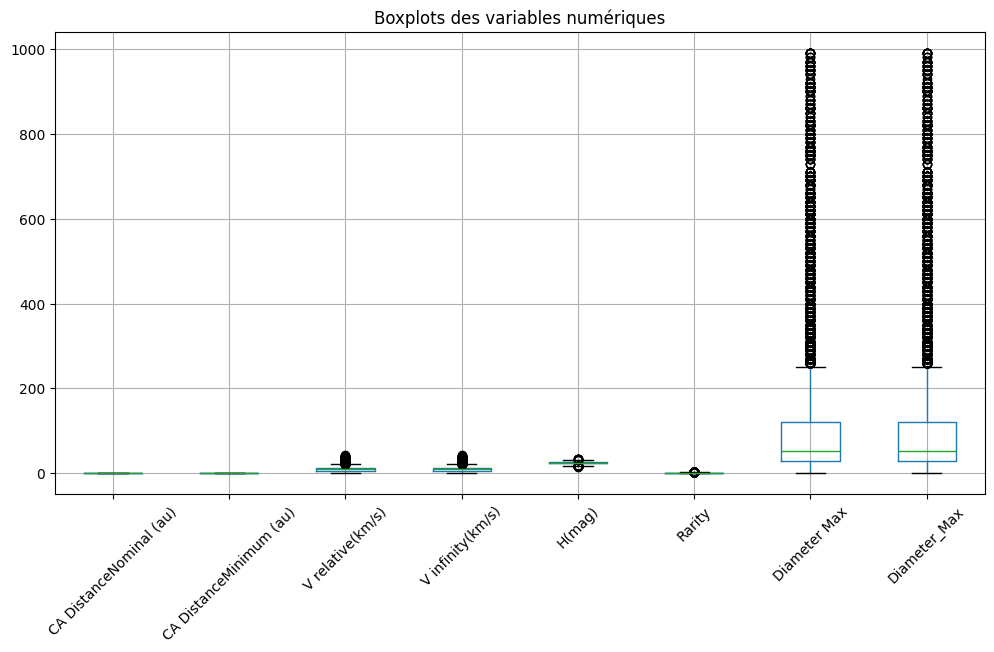

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
df.boxplot()
plt.title("Boxplots des variables numériques")
plt.xticks(rotation=45)
plt.show()


In [7]:
# Séparer features et target avant l'agrégation
target = df[["Close-Approach (CA) Date", "Rarity"]].copy()
features = df.drop(columns=["Rarity"]).copy()

# 1. Agrégation des features par jour
daily_features = features.groupby("Close-Approach (CA) Date").agg({
    "CA DistanceMinimum (au)": "mean",
    "V relative(km/s)": "mean",
    "H(mag)": "mean",
    "Diameter_Max": "mean"
})

# 2. Agrégation correcte de la target (mode = classe la plus fréquente)
daily_target = target.groupby("Close-Approach (CA) Date")["Rarity"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])

# 3. Fusion features + target
daily = daily_features.join(daily_target)

# 4. Forcer fréquence journalière
daily = daily.asfreq('D')
daily = daily.interpolate()

# 5. Interpolation uniquement des features (jamais la target)
daily[["CA DistanceMinimum (au)", 
       "V relative(km/s)", 
       "H(mag)", 
       "Diameter_Max"]] = daily[[
           "CA DistanceMinimum (au)",
           "V relative(km/s)",
           "H(mag)",
           "Diameter_Max"
       ]].interpolate()

# 6. La target ne doit jamais être interpolée → on garde les vraies valeurs
daily["Rarity"] = daily["Rarity"].ffill().bfill()

# Affichage
print(daily.head(20))


                          CA DistanceMinimum (au)  V relative(km/s)  \
Close-Approach (CA) Date                                              
1900-01-04 00:02:00                      0.009620          8.690000   
1900-01-05 00:02:00                      0.010355          8.735135   
1900-01-06 00:02:00                      0.011089          8.780270   
1900-01-07 00:02:00                      0.011824          8.825405   
1900-01-08 00:02:00                      0.012558          8.870541   
1900-01-09 00:02:00                      0.013293          8.915676   
1900-01-10 00:02:00                      0.014028          8.960811   
1900-01-11 00:02:00                      0.014762          9.005946   
1900-01-12 00:02:00                      0.015497          9.051081   
1900-01-13 00:02:00                      0.016231          9.096216   
1900-01-14 00:02:00                      0.016966          9.141351   
1900-01-15 00:02:00                      0.017701          9.186486   
1900-0

In [8]:
daily.isnull().sum()


CA DistanceMinimum (au)    0
V relative(km/s)           0
H(mag)                     0
Diameter_Max               0
Rarity                     0
dtype: int64

In [9]:
daily.columns

Index(['CA DistanceMinimum (au)', 'V relative(km/s)', 'H(mag)', 'Diameter_Max',
       'Rarity'],
      dtype='str')

In [10]:
# ===============================
# 0. Préparation des données daily
# ===============================

# Assurer que l’index est bien en datetime
daily.index = pd.to_datetime(daily.index)

# Trier chronologiquement
daily = daily.sort_index()

# Re-échantillonnage en journalier
daily = daily.asfreq('D')

# Interpolation linéaire (AVANT création des lags !)
daily = daily.interpolate(method='linear')

# ===============================
# 1. Features temporelles
# ===============================

daily["day"] = daily.index.day
daily["month"] = daily.index.month
daily["year"] = daily.index.year

# ===============================
# 2. Lags sur Rarity
# ===============================

daily["rarity_lag_1"]   = daily["Rarity"].shift(1)
daily["rarity_lag_7"]   = daily["Rarity"].shift(7)
daily["rarity_lag_30"]  = daily["Rarity"].shift(30)
daily["rarity_lag_90"]  = daily["Rarity"].shift(90)
daily["rarity_lag_180"] = daily["Rarity"].shift(180)
daily["rarity_lag_365"] = daily["Rarity"].shift(365)

# ===============================
# 3. Rolling windows SANS fuite future
# ===============================

daily["rarity_roll_7"]   = daily["Rarity"].shift(1).rolling(7,   min_periods=1).mean()
daily["rarity_roll_30"]  = daily["Rarity"].shift(1).rolling(30,  min_periods=1).mean()
daily["rarity_roll_90"]  = daily["Rarity"].shift(1).rolling(90,  min_periods=1).mean()
daily["rarity_roll_180"] = daily["Rarity"].shift(1).rolling(180, min_periods=1).mean()
daily["rarity_roll_365"] = daily["Rarity"].shift(1).rolling(365, min_periods=1).mean()

# ===============================
# 4. Supprimer les NaN causés par les lags
# ===============================

daily = daily.dropna()

# ===============================
# 5. Vérification finale
# ===============================

print("Daily shape :", daily.shape)
print(daily.head())


Daily shape : (109532, 19)
                          CA DistanceMinimum (au)  V relative(km/s)  \
Close-Approach (CA) Date                                              
1901-01-04 00:02:00                      0.027994         19.785660   
1901-01-05 00:02:00                      0.027966         19.745157   
1901-01-06 00:02:00                      0.027938         19.704654   
1901-01-07 00:02:00                      0.027910         19.664151   
1901-01-08 00:02:00                      0.027882         19.623648   

                             H(mag)  Diameter_Max  Rarity  day  month  year  \
Close-Approach (CA) Date                                                      
1901-01-04 00:02:00       21.307547    332.075472     1.0    4      1  1901   
1901-01-05 00:02:00       21.311321    331.446541     1.0    5      1  1901   
1901-01-06 00:02:00       21.315094    330.817610     1.0    6      1  1901   
1901-01-07 00:02:00       21.318868    330.188679     1.0    7      1  1901   
1

In [11]:
daily.columns

Index(['CA DistanceMinimum (au)', 'V relative(km/s)', 'H(mag)', 'Diameter_Max',
       'Rarity', 'day', 'month', 'year', 'rarity_lag_1', 'rarity_lag_7',
       'rarity_lag_30', 'rarity_lag_90', 'rarity_lag_180', 'rarity_lag_365',
       'rarity_roll_7', 'rarity_roll_30', 'rarity_roll_90', 'rarity_roll_180',
       'rarity_roll_365'],
      dtype='str')

In [12]:
print(daily["Rarity"].value_counts())

Rarity
1.000000    20026
0.000000    19995
2.000000     3070
3.000000      206
0.500000      168
            ...  
0.005669        1
0.004535        1
0.003401        1
0.002268        1
0.001134        1
Name: count, Length: 42391, dtype: int64


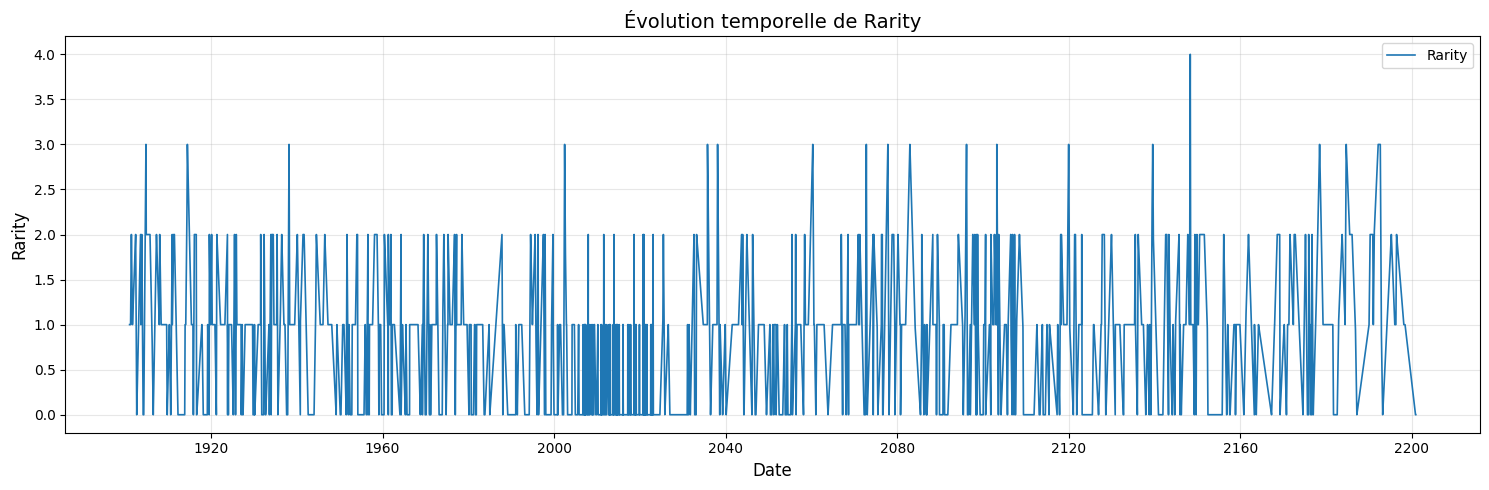

In [13]:
import matplotlib.pyplot as plt

# Vérifier que l'index est datetime pour éviter les warnings / erreurs
daily.index = pd.to_datetime(daily.index)

plt.figure(figsize=(15,5))

# Courbe plus lisse et lisible
plt.plot(daily.index, daily["Rarity"], label="Rarity", linewidth=1.2)

plt.title("Évolution temporelle de Rarity", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Rarity", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

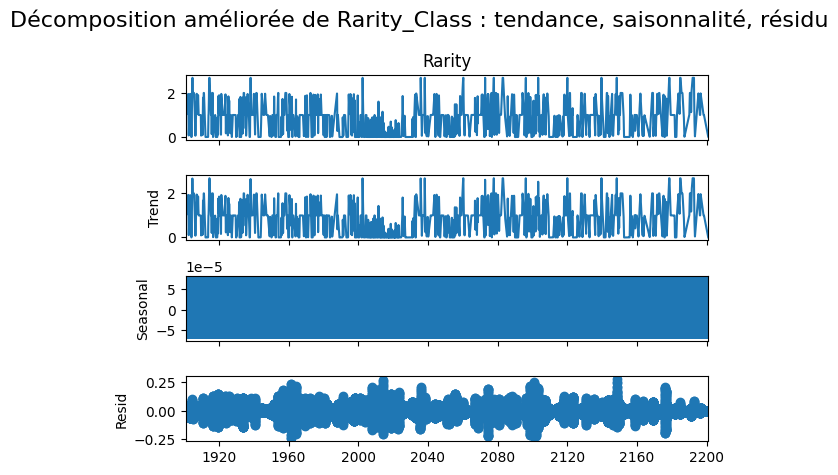

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ---------------------------------------------------------
# 1. S'assurer que l'index est en datetime
# ---------------------------------------------------------
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

# ---------------------------------------------------------
# 2. Resampling journalier (si plusieurs valeurs / jour)
# ---------------------------------------------------------
daily_resampled = daily["Rarity"].resample("1D").mean().fillna(0)

# ---------------------------------------------------------
# 3. Lissage (moving average)
# ---------------------------------------------------------
daily_smoothed = daily_resampled.rolling(window=30, center=True).mean()
daily_smoothed = daily_smoothed.bfill().ffill()

# ---------------------------------------------------------
# 4. Nettoyage des valeurs extrêmes (outliers)
# ---------------------------------------------------------
q1 = daily_smoothed.quantile(0.01)
q99 = daily_smoothed.quantile(0.99)
daily_clean = daily_smoothed.clip(lower=q1, upper=q99)

# ---------------------------------------------------------
# 5. Décomposition seasonal_decompose
# ---------------------------------------------------------
result = seasonal_decompose(daily_clean, model='additive', period=30)

# ---------------------------------------------------------
# 6. Affichage
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle("Décomposition améliorée de Rarity_Class : tendance, saisonnalité, résidu",
             fontsize=16)
plt.tight_layout()
plt.show()


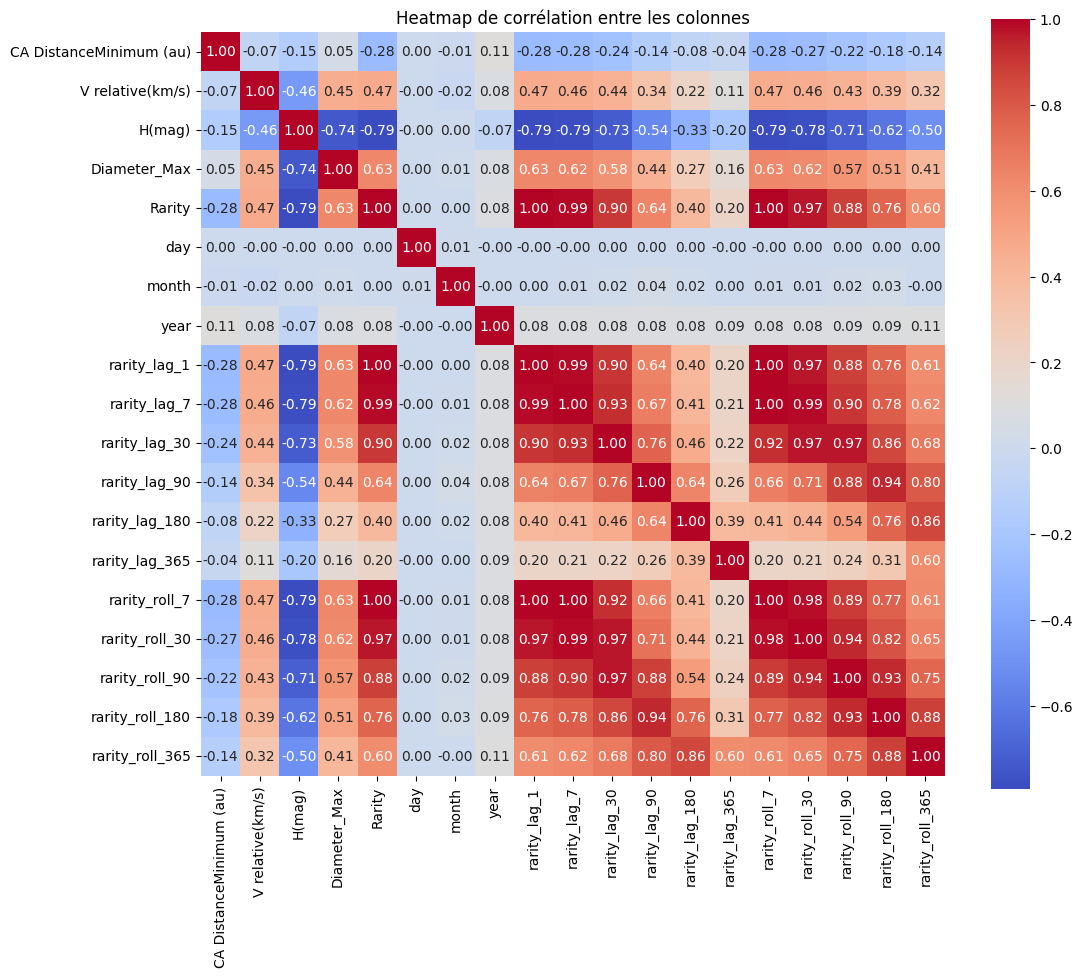

Colonnes fortement corrélées avec Rarity_Class :
rarity_lag_1        0.999360
rarity_roll_7       0.995168
rarity_lag_7        0.986664
rarity_roll_30      0.968012
rarity_lag_30       0.899308
rarity_roll_90      0.875635
rarity_roll_180     0.757775
rarity_lag_90       0.640921
Diameter_Max        0.626693
rarity_roll_365     0.602573
V relative(km/s)    0.467673
rarity_lag_180      0.396982
H(mag)             -0.794319
Name: Rarity, dtype: float64


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la corrélation
corr_matrix = daily.corr()

# Heatmap complète
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Heatmap de corrélation entre les colonnes")
plt.show()

# Filtrer les colonnes fortement corrélées avec Rarity_Class
threshold = 0.3  # Seuil de corrélation
corr_target = corr_matrix["Rarity"].drop("Rarity")  # exclure la cible elle-même
strong_corr = corr_target[abs(corr_target) >= threshold].sort_values(ascending=False)

print("Colonnes fortement corrélées avec Rarity_Class :")
print(strong_corr)


In [16]:
# Assurer que l’index est bien en datetime
daily.index = pd.to_datetime(daily.index)

# Définition du point temporel 2025
split_date = "2025-01-01"

train = daily.loc[daily.index < split_date]
test  = daily.loc[daily.index >= split_date]

print("Taille train :", train.shape)
print("Taille test  :", test.shape)


Taille train : (45288, 19)
Taille test  : (64244, 19)


In [17]:
features = [
    "rarity_lag_1",
    "rarity_lag_30",
    "rarity_lag_180",
    "rarity_lag_90",
    "rarity_roll_7",
    "rarity_roll_90",
    "Diameter_Max",
    "V relative(km/s)",
    "H(mag)"
]

target = "Rarity"


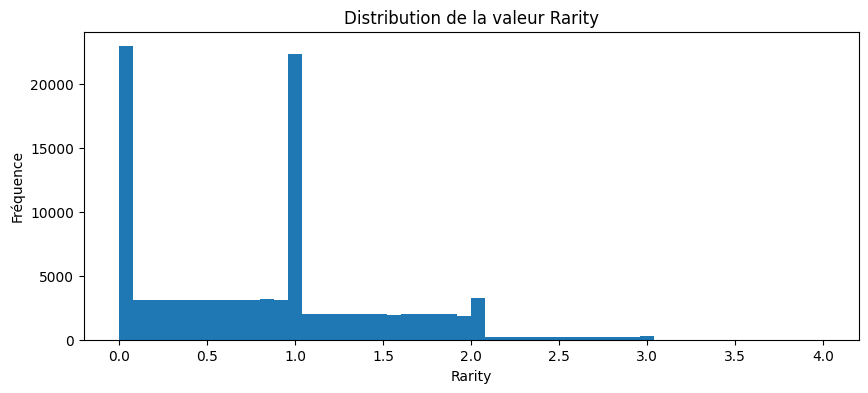

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(daily["Rarity"], bins=50)
plt.title("Distribution de la valeur Rarity")
plt.xlabel("Rarity")
plt.ylabel("Fréquence")
plt.show()


In [19]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler sauvegardé ✔️")


Scaler sauvegardé ✔️


In [21]:
import numpy as np

# -----------------------------
# Fonction de fenêtrage LSTM
# -----------------------------
def create_sequences(X, y, seq_length):
    X_seqs, y_seqs = [], []
    for i in range(len(X) - seq_length):
        X_seqs.append(X[i:i + seq_length])
        y_seqs.append(y[i + seq_length])
    return np.array(X_seqs), np.array(y_seqs)

# Choix longueur des séquences
SEQ_LEN = 30   # tu peux mettre 60 / 90 pour tester

# -----------------------------
# Créer les séquences train/test
# -----------------------------
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled, y_test.values, SEQ_LEN)

print("X_train_seq :", X_train_seq.shape)
print("y_train_seq :", y_train_seq.shape)

print("X_test_seq  :", X_test_seq.shape)
print("y_test_seq  :", y_test_seq.shape)


X_train_seq : (45258, 30, 9)
y_train_seq : (45258,)
X_test_seq  : (64214, 30, 9)
y_test_seq  : (64214,)


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------------
# Modèle Random Forest
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Entraînement
rf.fit(X_train_scaled, y_train)

# Prédiction
y_pred_rf = rf.predict(X_test_scaled)

# -----------------------------
# Évaluation
# -----------------------------
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("📌 Random Forest Regressor")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)


📌 Random Forest Regressor
MAE  : 0.005022766716453475
RMSE : 0.029849102517064113


In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------------
# Modèle Gradient Boosting
# -----------------------------
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Entraînement
gbr.fit(X_train_scaled, y_train)

# Prédiction
y_pred_gbr = gbr.predict(X_test_scaled)

# -----------------------------
# Évaluation
# -----------------------------
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("📌 Gradient Boosting Regressor")
print("MAE  :", mae_gbr)
print("RMSE :", rmse_gbr)


📌 Gradient Boosting Regressor
MAE  : 0.0068864375949871095
RMSE : 0.026259562656497416


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0150 - mae: 0.0561 - val_loss: 0.0279 - val_mae: 0.0964
Epoch 2/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0339 - val_loss: 0.0208 - val_mae: 0.0633
Epoch 3/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0028 - mae: 0.0301 - val_loss: 0.0194 - val_mae: 0.0677
Epoch 4/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0023 - mae: 0.0253 - val_loss: 0.0180 - val_mae: 0.0569
Epoch 5/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019 - mae: 0.0233 - val_loss: 0.0163 - val_mae: 0.0521
Epoch 6/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019 - mae: 0.0232 - val_loss: 0.0153 - val_mae: 0.0493
Epoch 7/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0018 - mae: 0.0231 - val_loss: 0.0150 - val_mae: 0.0497
Epoch 8/50
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0016 - mae: 0.0210 - val_loss: 0.0149 - val_mae: 0.0514
Epoch 9/50
1132/1132 ━━━━━━━━━━━━━━━━━━━

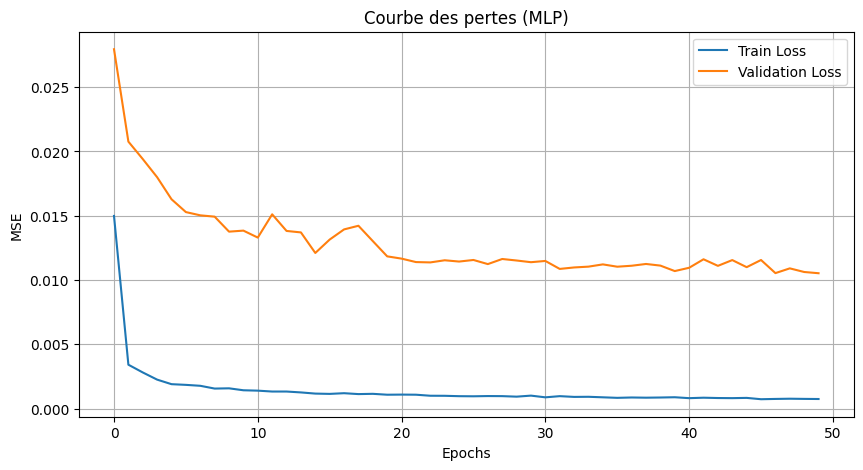

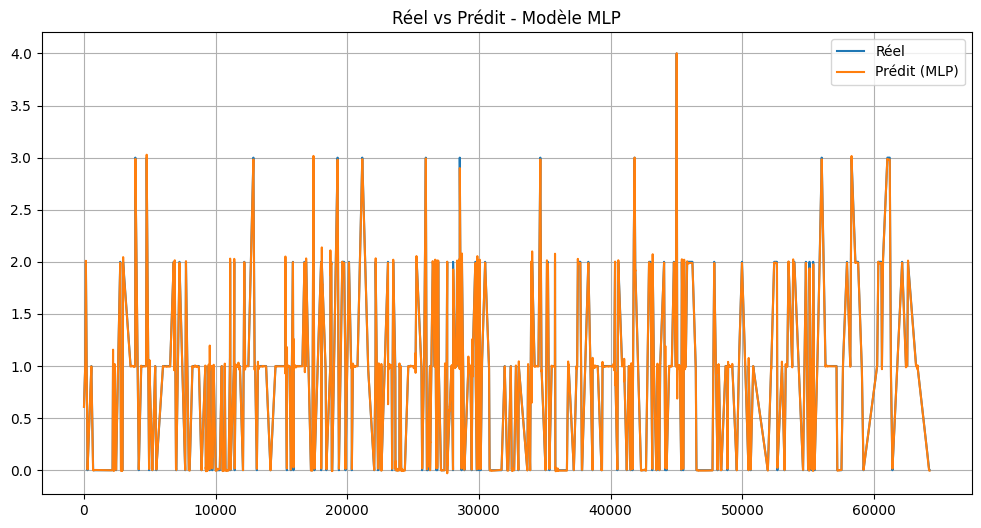

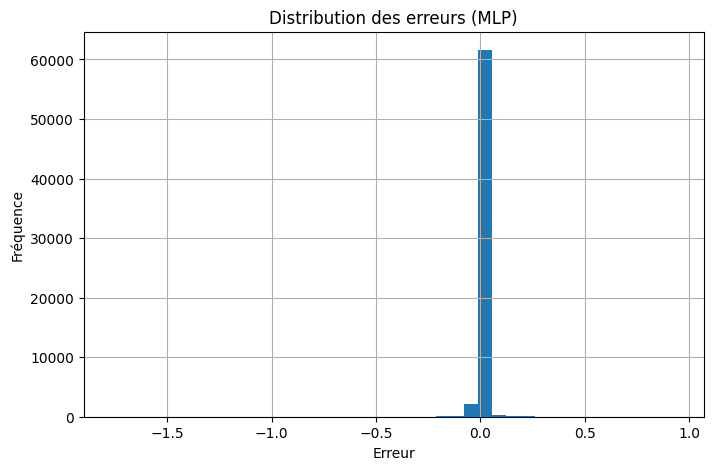

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# 1. Fenêtrage
# -----------------------------
SEQ_LEN = 30  # tu peux ajuster

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values, SEQ_LEN)

# -----------------------------
# 2. Modèle MLP Deep Learning
# -----------------------------
model_mlp = models.Sequential([
    layers.Flatten(input_shape=(SEQ_LEN, X_train.shape[1])),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mae']
)

# -----------------------------
# 3. Entraînement
# -----------------------------
history = model_mlp.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# -----------------------------
# 4. Prédictions
# -----------------------------
y_pred_mlp = model_mlp.predict(X_test_seq).flatten()

# -----------------------------
# 5. Métriques
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_mlp))
mae  = mean_absolute_error(y_test_seq, y_pred_mlp)
r2   = r2_score(y_test_seq, y_pred_mlp)

print("\n===== PERFORMANCES MLP =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

# -----------------------------
# 6. Courbe des Loss
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Courbe des pertes (MLP)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 7. Réel vs Prédit
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label="Réel")
plt.plot(y_pred_mlp, label="Prédit (MLP)")
plt.title("Réel vs Prédit - Modèle MLP")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 8. Distribution des erreurs
# -----------------------------
errors = y_test_seq - y_pred_mlp

plt.figure(figsize=(8,5))
plt.hist(errors, bins=40)
plt.title("Distribution des erreurs (MLP)")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.grid()
plt.show()


Shapes Avant Fenêtrage :
X_train_scaled: (45288, 9)
X_test_scaled : (64244, 9)

Shapes Après Fenêtrage :
X_train_seq: (45258, 30, 9)
X_test_seq : (64214, 30, 9)
y_train_seq: (45258,)
y_test_seq : (64214,)
Epoch 1/50


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1273/1273 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0152 - mae: 0.0442 - val_loss: 0.0188 - val_mae: 0.0659
Epoch 2/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0014 - mae: 0.0180 - val_loss: 0.0164 - val_mae: 0.0438
Epoch 3/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0011 - mae: 0.0152 - val_loss: 0.0163 - val_mae: 0.0522
Epoch 4/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 9.4602e-04 - mae: 0.0140 - val_loss: 0.0170 - val_mae: 0.0449
Epoch 5/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 7.9850e-04 - mae: 0.0124 - val_loss: 0.0150 - val_mae: 0.0404
Epoch 6/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 7.3039e-04 - mae: 0.0120 - val_loss: 0.0145 - val_mae: 0.0381
Epoch 7/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 6.5413e-04 - mae: 0.0113 - val_loss: 0.0133 - val_mae: 0.0374
Epoch 8/50
1273/1273 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5.9865e-04 - mae: 0.0105 - val_loss: 0.0144 - val_mae: 0.0351
Epoch 9/50
1273

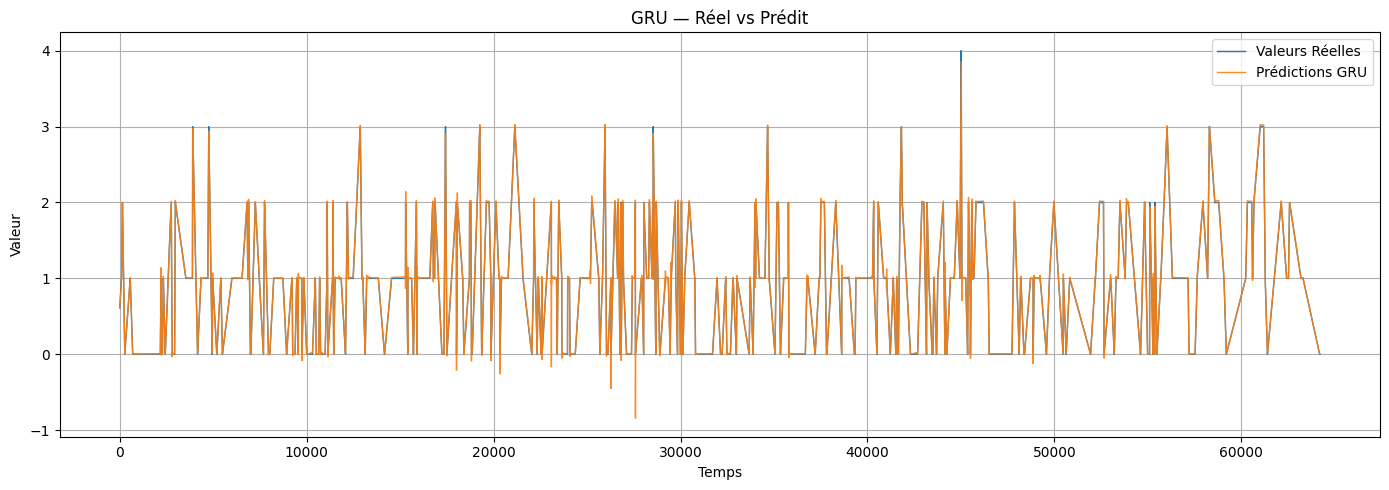

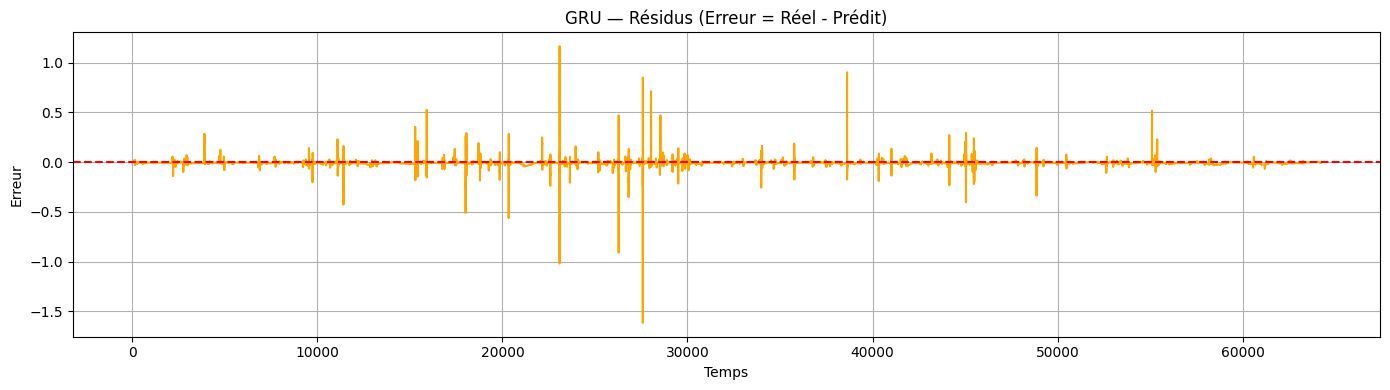

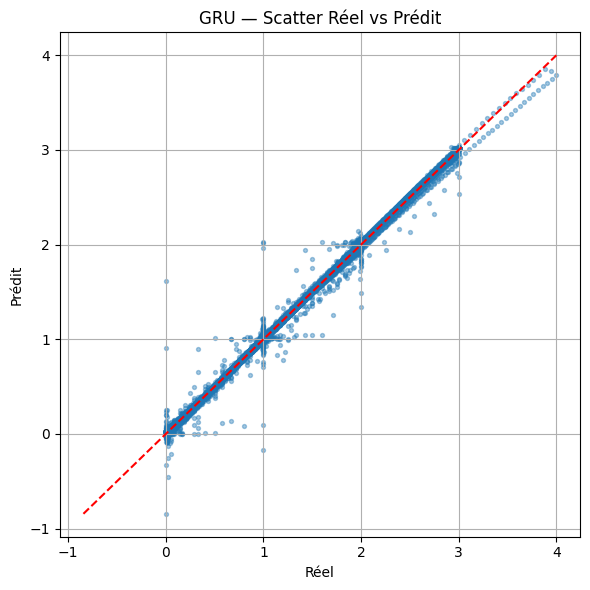

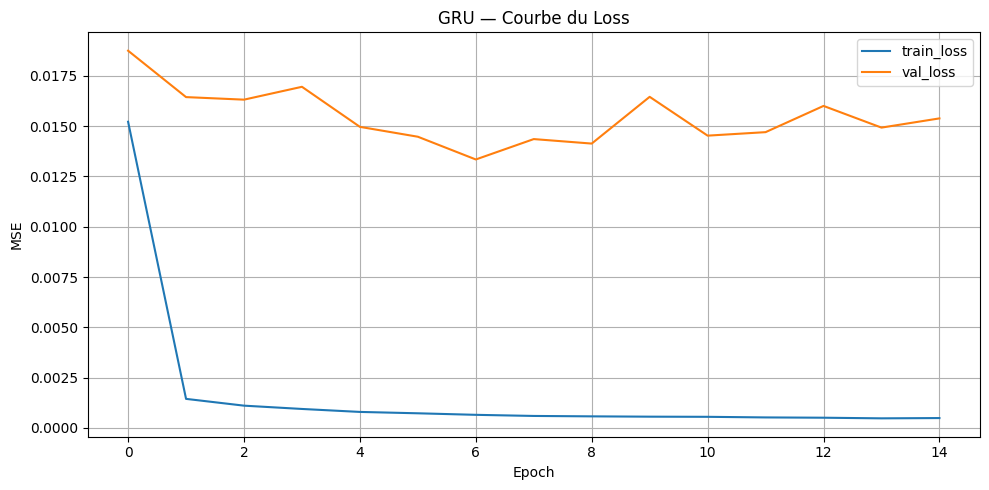

In [25]:
# ======================================================================
# ⭐ GRU COMPLET : Fenêtrage + Entraînement + Prédictions + Graphiques
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================
# 1) FENÊTRAGE (Sliding Window)
# =====================================================
def make_sequences(data, target, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(target[i+window])
    return np.array(X), np.array(y)

WINDOW = 30

# X_train_scaled et X_test_scaled doivent être 2D au départ
# Exemple shape : (45288, 9)
print("Shapes Avant Fenêtrage :")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

# Construire les séquences temporelles
X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train.values, WINDOW)
X_test_seq,  y_test_seq  = make_sequences(X_test_scaled,  y_test.values, WINDOW)

print("\nShapes Après Fenêtrage :")
print("X_train_seq:", X_train_seq.shape)   # => (n_samples, 30, 9)
print("X_test_seq :", X_test_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("y_test_seq :", y_test_seq.shape)

# =====================================================
# 2) ARCHITECTURE GRU
# =====================================================
timesteps  = X_train_seq.shape[1]   # 30
n_features = X_train_seq.shape[2]   # 9

model_gru = Sequential([
    GRU(64, activation='tanh', return_sequences=False, input_shape=(timesteps, n_features)),
    Dense(32, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

# EarlyStopping pour éviter overfitting
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# =====================================================
# 3) ENTRAÎNEMENT
# =====================================================
history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# =====================================================
# 4) PRÉDICTIONS
# =====================================================
y_pred_gru = model_gru.predict(X_test_seq).flatten()

# =====================================================
# 5) METRIQUES
# =====================================================
mae  = mean_absolute_error(y_test_seq, y_pred_gru)
mse  = mean_squared_error(y_test_seq, y_pred_gru)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_seq, y_pred_gru)

print("\n📌 PERFORMANCE DU MODÈLE GRU")
print("--------------------------------------")
print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

# =====================================================
# 6) VISUALISATION 1 : RÉEL VS PRÉDIT
# =====================================================
plt.figure(figsize=(14,5))
plt.plot(y_test_seq, label="Valeurs Réelles", linewidth=1)
plt.plot(y_pred_gru, label="Prédictions GRU", linewidth=1, alpha=0.9)
plt.title("GRU — Réel vs Prédit")
plt.xlabel("Temps")
plt.ylabel("Valeur")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 7) VISUALISATION 2 : RÉSIDUS
# =====================================================
residuals = y_test_seq - y_pred_gru

plt.figure(figsize=(14,4))
plt.plot(residuals, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.title("GRU — Résidus (Erreur = Réel - Prédit)")
plt.xlabel("Temps")
plt.ylabel("Erreur")
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 8) VISUALISATION 3 : SCATTER RÉEL VS PRÉDIT
# =====================================================
plt.figure(figsize=(6,6))
plt.scatter(y_test_seq, y_pred_gru, s=8, alpha=0.4)
lim_min = min(min(y_test_seq), min(y_pred_gru))
lim_max = max(max(y_test_seq), max(y_pred_gru))
plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', linestyle='--')
plt.title("GRU — Scatter Réel vs Prédit")
plt.xlabel("Réel")
plt.ylabel("Prédit")
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# 9) VISUALISATION 4 : COURBE D'ENTRAÎNEMENT
# =====================================================
plt.figure(figsize=(10,5))
plt.plot(history_gru.history['loss'], label='train_loss')
plt.plot(history_gru.history['val_loss'], label='val_loss')
plt.title("GRU — Courbe du Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Shapes :
X_train_seq: (45258, 30, 9)
X_test_seq : (64214, 30, 9)
y_train_seq: (45258,)
y_test_seq : (64214,)


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,537 (131.00 KB)

 Trainable params: 33,249 (129.88 KB)

 Non-trainable params: 288 (1.12 KB)

Epoch 1/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.2182 - val_loss: 0.0594 - learning_rate: 0.0010
Epoch 2/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 0.0393 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 3/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 0.0300 - val_loss: 0.0381 - learning_rate: 0.0010
Epoch 4/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.0269 - val_loss: 0.0356 - learning_rate: 0.0010
Epoch 5/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.0236 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 6/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.0221 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 7/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 0.0186 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 8/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.0165 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 9/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - loss: 0.0154 - val_loss: 0.0188 - learn

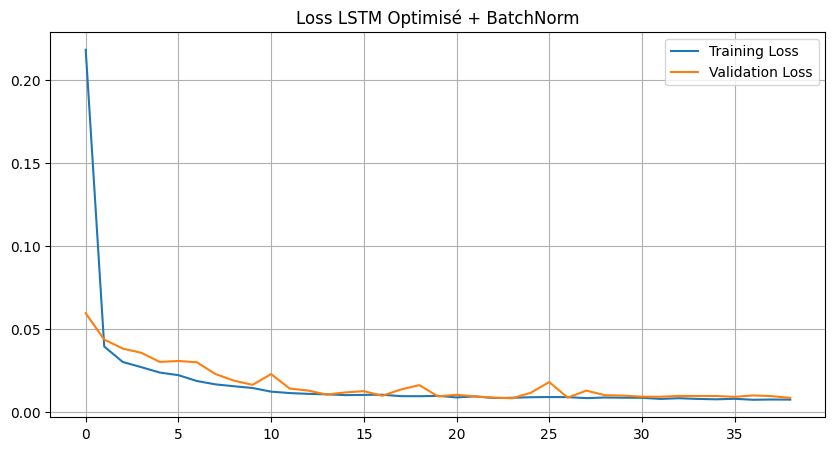

2007/2007 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step
===== METRIQUES LSTM OPTIMISÉ =====
RMSE : 0.03913619064082785
MAE  : 0.028633268398239015
R²   : 0.9966466616123657


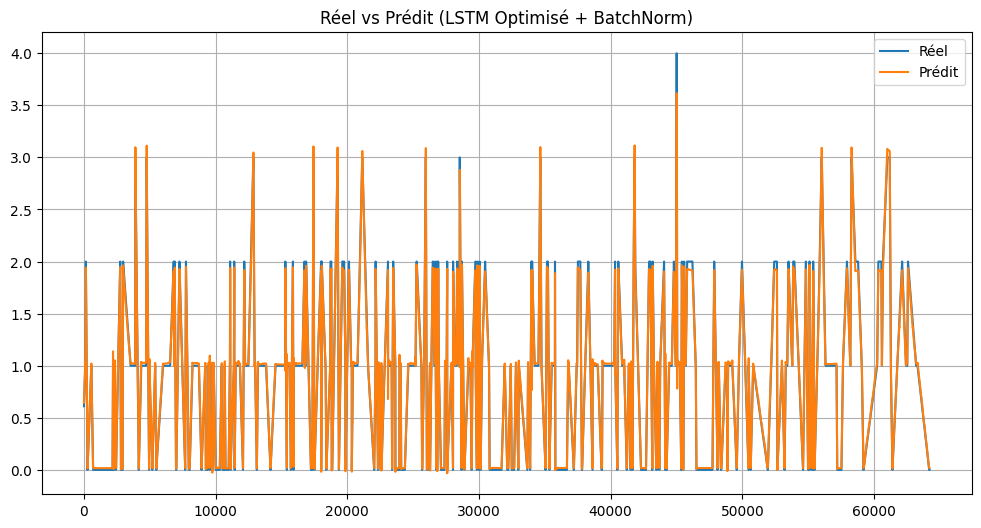

In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================
# 1) FENETRAGE DES DONNÉES
# =====================================================
def create_sequences(X, y, seq_len=30):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

seq_len = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_len)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values, seq_len)

print("Shapes :")
print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("y_test_seq :", y_test_seq.shape)

# =====================================================
# 2) MODELE LSTM OPTIMISÉ + BatchNormalization
# =====================================================
model = Sequential([

    # --- LSTM 1 ---
    LSTM(64, return_sequences=True,
         kernel_regularizer=l2(1e-4),
         input_shape=(seq_len, X_train_seq.shape[2])),
    BatchNormalization(),
    Dropout(0.2),

    # --- LSTM 2 ---
    LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    # --- Dense ---
    Dense(32, activation="relu"),
    BatchNormalization(),

    Dense(16, activation="relu"),
    BatchNormalization(),

    Dense(1)
])

model.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-5),
    loss="mse"
)

model.summary()

# =====================================================
# 3) CALLBACKS
# =====================================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    patience=5,
    factor=0.5,
    min_lr=1e-5
)

# =====================================================
# 4) ENTRAINEMENT
# =====================================================
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=150,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =====================================================
# 5) COURBE DES LOSSES
# =====================================================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss LSTM Optimisé + BatchNorm")
plt.legend()
plt.grid()
plt.show()

# =====================================================
# 6) PRÉDICTION
# =====================================================
y_pred = model.predict(X_test_seq).flatten()

# =====================================================
# 7) MÉTRIQUES
# =====================================================
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
mae  = mean_absolute_error(y_test_seq, y_pred)
r2   = r2_score(y_test_seq, y_pred)

print("===== METRIQUES LSTM OPTIMISÉ =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

# =====================================================
# 8) VISU RÉEL vs PRÉDIT
# =====================================================
plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label="Réel")
plt.plot(y_pred, label="Prédit")
plt.title("Réel vs Prédit (LSTM Optimisé + BatchNorm)")
plt.legend()
plt.grid()
plt.show()


Shapes:
X_train_seq: (45258, 30, 9)
X_test_seq : (64214, 30, 9)


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,017 (211.00 KB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.2092 - mae: 0.2810 - val_loss: 0.0638 - val_mae: 0.1207 - learning_rate: 0.0010
Epoch 2/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0600 - mae: 0.1356 - val_loss: 0.0563 - val_mae: 0.0865 - learning_rate: 0.0010
Epoch 3/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0499 - mae: 0.1154 - val_loss: 0.0484 - val_mae: 0.0715 - learning_rate: 0.0010
Epoch 4/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0448 - mae: 0.1078 - val_loss: 0.0459 - val_mae: 0.0887 - learning_rate: 0.0010
Epoch 5/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0397 - mae: 0.0999 - val_loss: 0.0383 - val_mae: 0.0568 - learning_rate: 0.0010
Epoch 6/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0356 - mae: 0.0955 - val_loss: 0.0369 - val_mae: 0.0647 - learning_rate: 0.0010
Epoch 7/150
566/566 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0308 - mae: 0.0885 - val_loss: 0.0333 - val_mae: 0.0813 - learning_

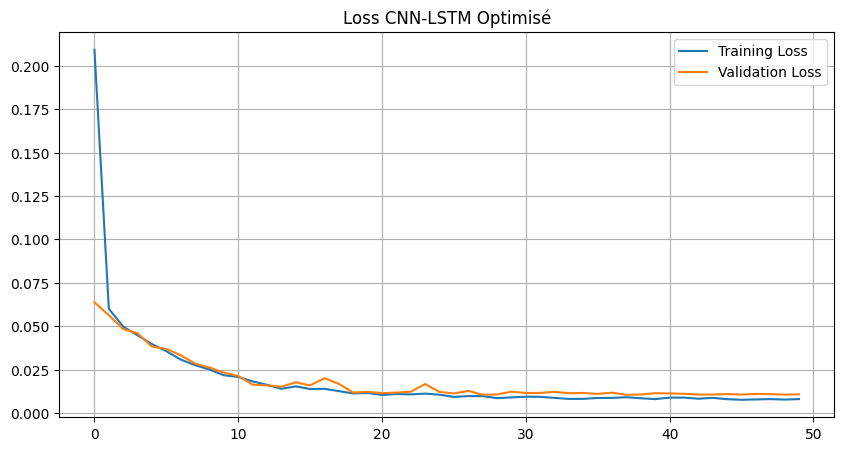

2007/2007 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


===== METRIQUES CNN-LSTM OPTIMISÉ =====
RMSE : 0.026215089305880988
MAE  : 0.013009147033128134
R²   : 0.9984953934022847


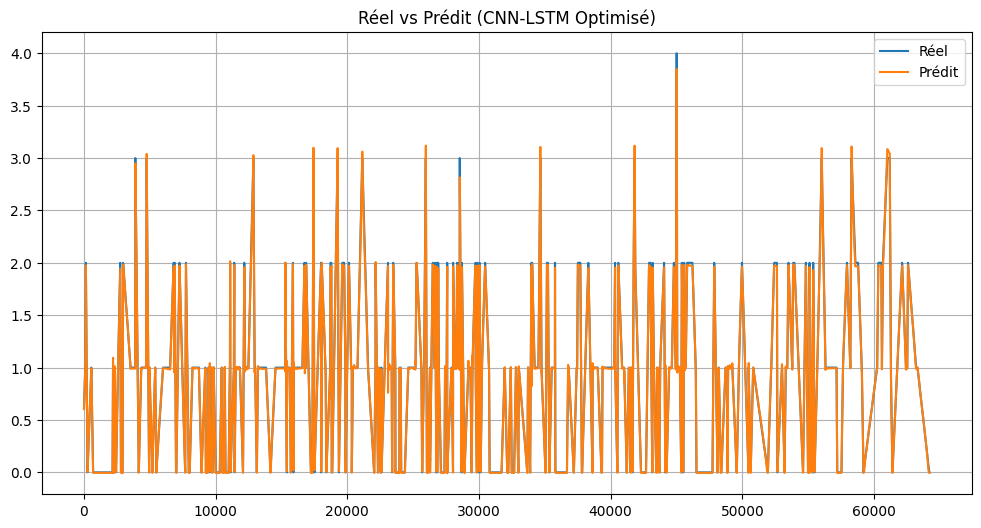

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# =====================================================
# 1) FENETRAGE
# =====================================================
def create_sequences(X, y, seq_len=30):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

seq_len = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_len)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test.values, seq_len)

print("Shapes:")
print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)

# =====================================================
# 2) MODELE CNN-LSTM OPTIMISÉ ET STABILISÉ
# =====================================================
model = Sequential([

    # ---- CNN BLOCK ----
    Conv1D(filters=64,
           kernel_size=3,
           padding="same",
           activation=None,
           kernel_regularizer=l2(1e-4),
           input_shape=(seq_len, X_train_seq.shape[2])),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    Conv1D(filters=64,
           kernel_size=3,
           padding="same",
           activation=None,
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # ---- LSTM ----
    LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.25),

    # ---- Dense BLOCK ----
    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    Dense(1)
])

model.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-5),
    loss="mse",
    metrics=["mae"]
)

model.summary()

# =====================================================
# 3) CALLBACKS
# =====================================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

# =====================================================
# 4) ENTRAINEMENT
# =====================================================
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=150,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =====================================================
# 5) COURBE DES LOSSES
# =====================================================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss CNN-LSTM Optimisé")
plt.legend()
plt.grid()
plt.show()

# =====================================================
# 6) PREDICTION
# =====================================================
y_pred = model.predict(X_test_seq).flatten()

# =====================================================
# 7) METRIQUES
# =====================================================
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
mae  = mean_absolute_error(y_test_seq, y_pred)
r2   = r2_score(y_test_seq, y_pred)

print("===== METRIQUES CNN-LSTM OPTIMISÉ =====")
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)
model.save("model_neo.h5")


# =====================================================
# 8) VISU RÉEL vs PRÉDIT
# =====================================================
plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label="Réel")
plt.plot(y_pred,    label="Prédit")
plt.title("Réel vs Prédit (CNN-LSTM Optimisé)")
plt.legend()
plt.grid()
plt.show()
